# 🔴 Dataset Selection and Reading

✅ First we upload file in drive and connect it to Collab

✅ then we import essential libraries we need

✅ use loop through the data_sets list read each JSON file (using pd.read_json) and store each one as a separate DataFrame in a list called data_read

✅ Finally use pd.concat() to combine all the DataFrames from your data_read list into one single, large DataFrame called df

In [88]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

data_sets = ['/content/drive/MyDrive/cmd_stop_event_logging_controlset_minint_key.json' ,
             '/content/drive/MyDrive/psh_stop_event_logging_controlset001_minint_key.json' ,
             '/content/drive/MyDrive/psh_stop_event_logging_controlset_minint_key.json' ,
             '/content/drive/MyDrive/reg_stop_event_logging_controlset001_minint_key.json' ,
             '/content/drive/MyDrive/reg_stop_event_logging_controlset_minint_key.json'
             ]

data_read = []
for data in data_sets :
  df_data = pd.read_json(data , lines = True)
  data_read.append(df_data)

df = pd.concat(data_read , ignore_index = True)
df

,SourceName,ProviderGuid,Level,Keywords,Channel,Hostname,TimeCreated,@timestamp,EventID,Message,...,UserData,Payload,ScriptBlockId,RunspaceId,MessageNumber,MessageTotal,ScriptBlockText,Path,param1,param2
0,Microsoft-Windows-Security-SPP,{E23B33B0-C8C9-472C-A5F9-F2BDFEA0F156},4,0x80000000000000,Application,Pedro01,2022-08-03T07:22:33.136Z,2022-08-03T07:22:33.136Z,16384,Successfully scheduled Software Protection ser...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Microsoft-Windows-Security-Auditing,{54849625-5478-4994-a5ba-3e3b0328c30d},0,0x8010000000000000,Security,Pedro01,2022-08-03T07:22:11.232Z,2022-08-03T07:22:11.232Z,4673,A privileged service was called.\r\n\r\nSubjec...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Microsoft-Windows-Security-Auditing,{54849625-5478-4994-a5ba-3e3b0328c30d},0,0x8010000000000000,Security,Pedro01,2022-08-03T07:22:11.373Z,2022-08-03T07:22:11.373Z,4673,A privileged service was called.\r\n\r\nSubjec...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Microsoft-Windows-Security-Auditing,{54849625-5478-4994-a5ba-3e3b0328c30d},0,0x8010000000000000,Security,Pedro01,2022-08-03T07:22:11.379Z,2022-08-03T07:22:11.379Z,4673,A privileged service was called.\r\n\r\nSubjec...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Microsoft-Windows-Security-Auditing,{54849625-5478-4994-a5ba-3e3b0328c30d},0,0x8020000000000000,Security,Pedro01,2022-08-03T07:22:11.497Z,2022-08-03T07:22:11.497Z,4689,A process has exited.\r\n\r\nSubject:\r\n\tSec...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31481,Microsoft-Windows-PowerShell,{a0c1853b-5c40-4b15-8766-3cf1c58f985a},4,0x0,Microsoft-Windows-PowerShell/Operational,Pedro01,2022-08-03T04:02:34.714Z,2022-08-03T04:02:34.714Z,4103,"CommandInvocation(Get-WinEvent): ""Get-WinEvent...",...,NaN,"CommandInvocation(Get-WinEvent): ""Get-WinEvent...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31482,Microsoft-Windows-PowerShell,{a0c1853b-5c40-4b15-8766-3cf1c58f985a},4,0x0,Microsoft-Windows-PowerShell/Operational,Pedro01,2022-08-03T04:02:34.717Z,2022-08-03T04:02:34.717Z,4103,"CommandInvocation(Write-Verbose): ""Write-Verbo...",...,NaN,"CommandInvocation(Write-Verbose): ""Write-Verbo...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31483,Microsoft-Windows-PowerShell,{a0c1853b-5c40-4b15-8766-3cf1c58f985a},4,0x0,Microsoft-Windows-PowerShell/Operational,Pedro01,2022-08-03T04:02:34.718Z,2022-08-03T04:02:34.718Z,4103,"CommandInvocation(Write-Verbose): ""Write-Verbo...",...,NaN,"CommandInvocation(Write-Verbose): ""Write-Verbo...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31484,Microsoft-Windows-PowerShell,{a0c1853b-5c40-4b15-8766-3cf1c58f985a},4,0x0,Microsoft-Windows-PowerShell/Operational,Pedro01,2022-08-03T04:02:34.719Z,2022-08-03T04:02:34.719Z,4103,"CommandInvocation(Write-Verbose): ""Write-Verbo...",...,NaN,"CommandInvocation(Write-Verbose): ""Write-Verbo...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN




*   Timestamp : Time of event on the device


*   Event ID : The event number that identifies the type of security activity





✅ Get quick information about the data :


*   169 columns
*   31485 rows



In [89]:
# info about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31486 entries, 0 to 31485
Columns: 169 entries, SourceName to param2
dtypes: float64(24), int64(3), object(142)
memory usage: 40.6+ MB


In [90]:
# columns with the most nan values
df.isna().sum().sort_values(ascending = False).head(20)

,0
UserData,31486
param1,31484
param2,31484
Session,31482
ClientInfo,31482
FailureReason,31481
Workstation,31481
SubStatus,31481
TargetLogonGuid,31481
TargetInfo,31481


# 🔴 Raw Log Parsing , Preprocessing and Cleaning Data

✅ Now we must eliminate duplicate classes to prevent any bias.

In [91]:
print(f'before eliminating we have {df.shape} rows and columns')
print(f'before eliminating we have {df.duplicated().sum()} duplicates')

df.drop_duplicates(inplace = True)

print()
print(f'after eliminating we have {df.shape} rows and columns')
print(f'after eliminating we have {df.duplicated().sum()} duplicates')

before eliminating we have (31486, 169) rows and columns
before eliminating we have 2255 duplicates

after eliminating we have (29231, 169) rows and columns
after eliminating we have 0 duplicates


In [92]:
df.dtypes.value_counts()

,count
object,142
float64,24
int64,3


✅ Here I have identified the most important features that will help me predict and put them into a new dataframe in order to get rid of the other features that contain large amounts of nan values.

In [93]:
# selecting important columns
important_cols = ['TimeCreated' ,  'EventID' , 'Channel' , 'SourceName' , 'SubjectUserName' ,
                  'ProcessName' , 'NewProcessName' , 'ParentProcessName' , 'IpAddress' ]

new_df = pd.DataFrame()

for col in important_cols:
    if col in df.columns:
        new_df[col] = df[col]
    else:
        new_df[col] = None

new_df.head(5)

,TimeCreated,EventID,Channel,SourceName,SubjectUserName,ProcessName,NewProcessName,ParentProcessName,IpAddress
0,2022-08-03T07:22:33.136Z,16384,Application,Microsoft-Windows-Security-SPP,NaN,NaN,NaN,NaN,NaN
1,2022-08-03T07:22:11.232Z,4673,Security,Microsoft-Windows-Security-Auditing,IT01-Pedro,C:\Windows\System32\RuntimeBroker.exe,NaN,NaN,NaN
2,2022-08-03T07:22:11.373Z,4673,Security,Microsoft-Windows-Security-Auditing,IT01-Pedro,C:\Windows\System32\RuntimeBroker.exe,NaN,NaN,NaN
3,2022-08-03T07:22:11.379Z,4673,Security,Microsoft-Windows-Security-Auditing,IT01-Pedro,C:\Windows\SystemApps\Microsoft.Windows.Cortan...,NaN,NaN,NaN
4,2022-08-03T07:22:11.497Z,4689,Security,Microsoft-Windows-Security-Auditing,IT01-Pedro,C:\Windows\System32\backgroundTaskHost.exe,NaN,NaN,NaN


In [94]:
new_df.isna().sum().sort_values(ascending = False)

,0
IpAddress,29205
ParentProcessName,29196
NewProcessName,29196
ProcessName,28951
SubjectUserName,28767
TimeCreated,0
SourceName,0
EventID,0
Channel,0


✅ We have a large number of NAN values so we will get rid of them by filling them in based on the eventid value.

✅ Each value of eventid has a specific meaning within the system such as


*   4624 – Successful Logon
*   4625 – Failed Logon and so on



In [95]:
def filling_nan_by_eventid(data) :
  def fill(col, val):
    if pd.isna(data[col]) :
      data[col] = val

  event = data["EventID"]
  src = str(data["SourceName"])

  if event == 4688 :
        fill('ProcessName' , 'ProcEvt_NoProcess')
        fill('NewProcessName' , 'ProcEvt_NoNew')
        fill('ParentProcessName' , 'ProcEvt_NoParent')
        fill('IpAddress' , 'ProcEvt_NoIP')
        fill('SubjectUserName' , 'ProcEvt_NoUser')

  elif event in [4624, 4625] :
        fill('ProcessName' , 'Logon_NoProcess')
        fill('NewProcessName' , 'Logon_NoNew')
        fill('ParentProcessName' , 'Logon_NoParent')
        fill('IpAddress' , 'Logon_NoIP')
        fill('SubjectUserName' , 'Logon_NoUser')

  elif event == 5379 :
        fill('ProcessName' , 'Cred_NoProcess')
        fill('NewProcessName' , 'Cred_NoNew')
        fill('ParentProcessName' , 'Cred_NoParent')
        fill('IpAddress' , 'Cred_NoIP')
        fill('SubjectUserName' , 'Cred_NoUser')

  elif event in [4656, 4658, 4670] :
        fill('ProcessName' , 'SAM_NoProcess')
        fill('NewProcessName' , 'SAM_NoNew')
        fill('ParentProcessName' , 'SAM_NoParent')
        fill('IpAddress' , 'SAM_NoIP')
        fill('SubjectUserName' , 'SAM_NoUser')

  elif "Sysmon" in src:
        fill('ProcessName' , 'Sysmon_NoProcess')
        fill('NewProcessName' , 'Sysmon_NoNew')
        fill('ParentProcessName' , 'Sysmon_NoParent')
        fill('IpAddress' , 'Sysmon_NoIP')
        fill('SubjectUserName' , 'Sysmon_NoUser')

  else:
        fill('ProcessName' , 'Unknown_Process')
        fill('NewProcessName' , 'Unknown_NewProcess')
        fill('ParentProcessName' , 'Unknown_Parent')
        fill('IpAddress' , 'Unknown_IP')
        fill('SubjectUserName' , 'Unknown_User')

  return data

new_df = new_df.apply(filling_nan_by_eventid , axis=1)
new_df.head(5)


,TimeCreated,EventID,Channel,SourceName,SubjectUserName,ProcessName,NewProcessName,ParentProcessName,IpAddress
0,2022-08-03T07:22:33.136Z,16384,Application,Microsoft-Windows-Security-SPP,Unknown_User,Unknown_Process,Unknown_NewProcess,Unknown_Parent,Unknown_IP
1,2022-08-03T07:22:11.232Z,4673,Security,Microsoft-Windows-Security-Auditing,IT01-Pedro,C:\Windows\System32\RuntimeBroker.exe,Unknown_NewProcess,Unknown_Parent,Unknown_IP
2,2022-08-03T07:22:11.373Z,4673,Security,Microsoft-Windows-Security-Auditing,IT01-Pedro,C:\Windows\System32\RuntimeBroker.exe,Unknown_NewProcess,Unknown_Parent,Unknown_IP
3,2022-08-03T07:22:11.379Z,4673,Security,Microsoft-Windows-Security-Auditing,IT01-Pedro,C:\Windows\SystemApps\Microsoft.Windows.Cortan...,Unknown_NewProcess,Unknown_Parent,Unknown_IP
4,2022-08-03T07:22:11.497Z,4689,Security,Microsoft-Windows-Security-Auditing,IT01-Pedro,C:\Windows\System32\backgroundTaskHost.exe,Unknown_NewProcess,Unknown_Parent,Unknown_IP


✅ since the machine learning models can't handle NaN therefore we replaced it with logical values based on EventID

✅ We have finished all of Nan's values

In [96]:
new_df.isna().sum()

,0
TimeCreated,0
EventID,0
Channel,0
SourceName,0
SubjectUserName,0
ProcessName,0
NewProcessName,0
ParentProcessName,0
IpAddress,0


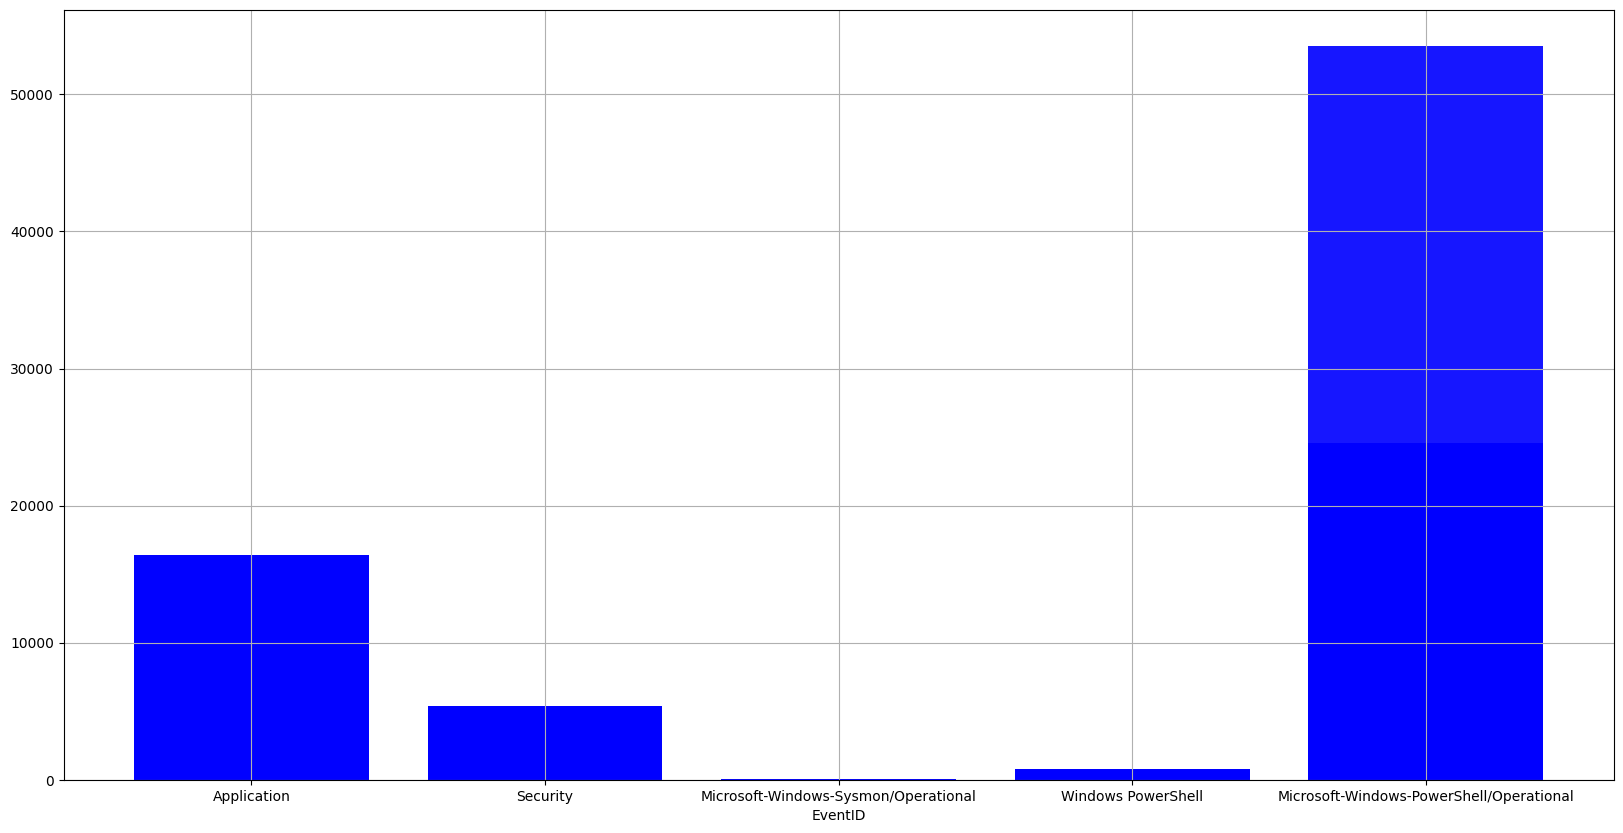

In [97]:
# The relationship between eventid and Channel
plt.figure(figsize = (20 , 10))
plt.bar(new_df['Channel'] , new_df['EventID'] , alpha = 0.7 , color = 'b' )
plt.xlabel('EventID')
plt.grid(True)
plt.show()

# 🔴	Feature Engineering

✅ We will apply feature engineering by creating new detailed columns from existing columns To help us predict its efficiency like (Date_creaated and UserEventFrequency and so on)

In [98]:
# ensure that the important columns have the correct data type.
new_df['TimeCreated'] = pd.to_datetime(new_df['TimeCreated'] , errors = 'coerce')

user_freq = new_df['SubjectUserName'].value_counts()
new_df['UserEventFrequency'] = new_df['SubjectUserName'].map(user_freq)

# => The importance of calculating time differences lies in its ability to detect rapid operations that occurred within fractions of a second by malicious code or an automated tool
# => lower Time_Difference higher danger
new_df['Time_Difference'] = (new_df['TimeCreated'] - new_df['TimeCreated'].shift(1)).dt.total_seconds().fillna(0)

new_df['ElevationOccurred'] = new_df['EventID'].isin([4672, 4673, 4703]).astype(int)

new_df['SAMAccess'] = new_df['EventID'].isin([4656, 4658, 4670]).astype(int)

new_df['ProcessFromDownloads'] = ((new_df['EventID'] == 4688) & (new_df['NewProcessName'].astype(str).str.contains(r'\\Downloads\\' , case = False , na = False))).astype(int)

new_df['IsPayloadLikeName'] = ((new_df['EventID'] == 4688) & (new_df['NewProcessName'].astype(str).str.contains(r'(payload|update|patch|setup|run)' , case = False , na = False))).astype(int)

new_df['IsProcessCreation'] = (new_df['EventID'] == 4688).astype(int)

new_df['IsPrivilegeEscalation'] = new_df['EventID'].isin([4672, 4673, 4703]).astype(int)

new_df['IsCredentialRead'] = (new_df['EventID'] == 5379).astype(int)

new_df['IsSAMAccess'] = new_df['EventID'].isin([4656, 4658, 4670]).astype(int)

new_df['IsLoginFail'] = (new_df['EventID'] == 4625).astype(int)

new_df['IsLoginSuccess'] = (new_df['EventID'] == 4624).astype(int)

new_df.head(5)


/tmp/ipython-input-1075290217.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  new_df['IsPayloadLikeName'] = ((new_df['EventID'] == 4688) & (new_df['NewProcessName'].astype(str).str.contains(r'(payload|update|patch|setup|run)' , case = False , na = False))).astype(int)


,TimeCreated,EventID,Channel,SourceName,SubjectUserName,ProcessName,NewProcessName,ParentProcessName,IpAddress,UserEventFrequency,...,ElevationOccurred,SAMAccess,ProcessFromDownloads,IsPayloadLikeName,IsProcessCreation,IsPrivilegeEscalation,IsCredentialRead,IsSAMAccess,IsLoginFail,IsLoginSuccess
0,2022-08-03 07:22:33.136000+00:00,16384,Application,Microsoft-Windows-Security-SPP,Unknown_User,Unknown_Process,Unknown_NewProcess,Unknown_Parent,Unknown_IP,578,...,0,0,0,0,0,0,0,0,0,0
1,2022-08-03 07:22:11.232000+00:00,4673,Security,Microsoft-Windows-Security-Auditing,IT01-Pedro,C:\Windows\System32\RuntimeBroker.exe,Unknown_NewProcess,Unknown_Parent,Unknown_IP,101,...,1,0,0,0,0,1,0,0,0,0
2,2022-08-03 07:22:11.373000+00:00,4673,Security,Microsoft-Windows-Security-Auditing,IT01-Pedro,C:\Windows\System32\RuntimeBroker.exe,Unknown_NewProcess,Unknown_Parent,Unknown_IP,101,...,1,0,0,0,0,1,0,0,0,0
3,2022-08-03 07:22:11.379000+00:00,4673,Security,Microsoft-Windows-Security-Auditing,IT01-Pedro,C:\Windows\SystemApps\Microsoft.Windows.Cortan...,Unknown_NewProcess,Unknown_Parent,Unknown_IP,101,...,1,0,0,0,0,1,0,0,0,0
4,2022-08-03 07:22:11.497000+00:00,4689,Security,Microsoft-Windows-Security-Auditing,IT01-Pedro,C:\Windows\System32\backgroundTaskHost.exe,Unknown_NewProcess,Unknown_Parent,Unknown_IP,101,...,0,0,0,0,0,0,0,0,0,0


In [99]:
new_df['TimeCreated'] = new_df['TimeCreated'].astype('int64') // 10**9

In [100]:
new_df.dtypes.value_counts()

,count
int64,13
object,7
float64,1


✅ Converting catigorical values ​​to numerical values using LabelEncoder

In [101]:
from sklearn.preprocessing import LabelEncoder
obj_cols = new_df.select_dtypes(include = 'object').columns
for col in obj_cols :
    m1 = LabelEncoder()
    new_df[col] = m1.fit_transform(new_df[[col]])
new_df

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

,TimeCreated,EventID,Channel,SourceName,SubjectUserName,ProcessName,NewProcessName,ParentProcessName,IpAddress,UserEventFrequency,...,ElevationOccurred,SAMAccess,ProcessFromDownloads,IsPayloadLikeName,IsProcessCreation,IsPrivilegeEscalation,IsCredentialRead,IsSAMAccess,IsLoginFail,IsLoginSuccess
0,1659511353,16384,0,2,5,18,14,9,6,578,...,0,0,0,0,0,0,0,0,0,0
1,1659511331,4673,3,1,0,1,14,9,6,101,...,1,0,0,0,0,1,0,0,0,0
2,1659511331,4673,3,1,0,1,14,9,6,101,...,1,0,0,0,0,1,0,0,0,0
3,1659511331,4673,3,1,0,13,14,9,6,101,...,1,0,0,0,0,1,0,0,0,0
4,1659511331,4689,3,1,0,3,14,9,6,101,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31481,1659499354,4103,1,0,5,18,14,9,6,578,...,0,0,0,0,0,0,0,0,0,0
31482,1659499354,4103,1,0,5,18,14,9,6,578,...,0,0,0,0,0,0,0,0,0,0
31483,1659499354,4103,1,0,5,18,14,9,6,578,...,0,0,0,0,0,0,0,0,0,0
31484,1659499354,4103,1,0,5,18,14,9,6,578,...,0,0,0,0,0,0,0,0,0,0


✅ Scaling data using standerd scaler only on numerical values

In [102]:
from sklearn.preprocessing import StandardScaler

col_to_scale = ['TimeCreated' , 'UserEventFrequency' , 'Time_Difference' , 'EventID']
new_df[col_to_scale] = StandardScaler().fit_transform(new_df[col_to_scale])
new_df

,TimeCreated,EventID,Channel,SourceName,SubjectUserName,ProcessName,NewProcessName,ParentProcessName,IpAddress,UserEventFrequency,...,ElevationOccurred,SAMAccess,ProcessFromDownloads,IsPayloadLikeName,IsProcessCreation,IsPrivilegeEscalation,IsCredentialRead,IsSAMAccess,IsLoginFail,IsLoginSuccess
0,2.030572,17.122949,0,2,5,18,14,9,6,-5.168684,...,0,0,0,0,0,0,0,0,0,0
1,2.025212,4.768828,3,1,0,1,14,9,6,-5.261298,...,1,0,0,0,0,1,0,0,0,0
2,2.025212,4.768828,3,1,0,1,14,9,6,-5.261298,...,1,0,0,0,0,1,0,0,0,0
3,2.025212,4.768828,3,1,0,13,14,9,6,-5.261298,...,1,0,0,0,0,1,0,0,0,0
4,2.025212,4.785706,3,1,0,3,14,9,6,-5.261298,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31481,-0.892548,4.167526,1,0,5,18,14,9,6,-5.168684,...,0,0,0,0,0,0,0,0,0,0
31482,-0.892548,4.167526,1,0,5,18,14,9,6,-5.168684,...,0,0,0,0,0,0,0,0,0,0
31483,-0.892548,4.167526,1,0,5,18,14,9,6,-5.168684,...,0,0,0,0,0,0,0,0,0,0
31484,-0.892548,4.167526,1,0,5,18,14,9,6,-5.168684,...,0,0,0,0,0,0,0,0,0,0


# 🔴 Clustering for Risk Level Assignment

✅ using PCA to reduce dimensions for K-means clustring

In [103]:
from sklearn.decomposition import PCA
most_imp_features = ['TimeCreated' , 'UserEventFrequency' , 'Time_Difference' , 'EventID' , 'ElevationOccurred',
                     'SAMAccess' , 'ProcessFromDownloads' , 'IsPayloadLikeName' , 'IsProcessCreation' , 'IsPrivilegeEscalation' ,
                     'IsCredentialRead' , 'IsSAMAccess' , 'IsLoginFail' , 'IsLoginSuccess']


X = new_df[most_imp_features]

pca = PCA(n_components = 2 , random_state = 42)
pca_result = pca.fit_transform(X)
new_df['PCA1'] = pca_result[ : , 0]
new_df['PCA2'] = pca_result[ : , 1]

✅ Applying Elbow method in order to find the best value for (K)

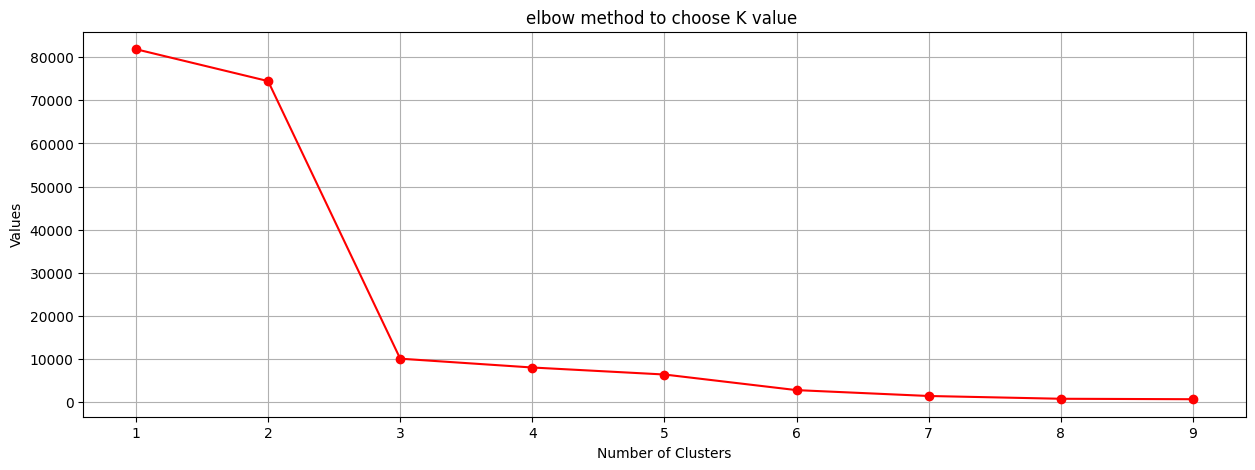

In [104]:
from sklearn.cluster import KMeans

values = []
n_clusters = range(1 , 10)
for k in n_clusters :
  model = KMeans(n_clusters = k , random_state = 42).fit(pca_result)
  values.append(model.inertia_)

plt.figure(figsize=(15 , 5))
plt.plot(n_clusters , values , marker = 'o' , c = 'r')
plt.title('elbow method to choose K value ')
plt.xlabel('Number of Clusters')
plt.ylabel('Values')
plt.grid(True)
plt.show()

✅ Apply K-Means clustering on parsed features to group log entries and assigning risk levels (low, medium, high) to clusters

In [105]:
# best value (K = 3)
kmeans = KMeans(n_clusters = 3 , random_state = 42)
new_df['Risk_Cluster'] = kmeans.fit_predict(new_df[['PCA1' , 'PCA2']])

cluster_scores = new_df.groupby('Risk_Cluster')[most_imp_features].mean().mean(axis = 1)
order = cluster_scores.argsort()

risk_map = { order[0] : 'High' ,
            order[1] : 'Medium' ,
             order[2] : 'Low'}

new_df['Risk_Level'] = new_df['Risk_Cluster'].map(risk_map)
new_df['Risk_Level'].value_counts()

,count
Risk_Level,
Medium,23026
Low,5163
High,1042


✅ visualize kmeans clusters

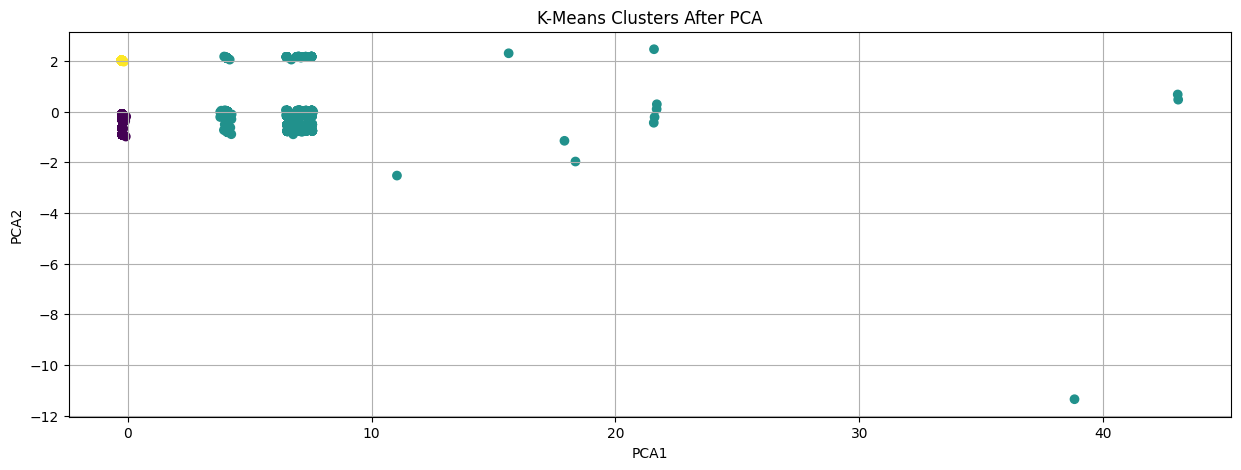

In [106]:
plt.figure(figsize = (15 , 5))
plt.scatter(new_df['PCA1'] , new_df['PCA2'] , c = new_df['Risk_Cluster']  )
plt.title('K-Means Clusters After PCA')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.grid(True)
plt.show()

# 🔴 Model Development

In [107]:
features = [c for c in most_imp_features if c in new_df.columns]

# focus on low and medium risk levels so that it is not considered an anomaly
mask = (new_df['Risk_Level'] == 'Low') | (new_df['Risk_Level'] == 'Medium')

X_train = new_df.loc[mask , features]
X = new_df[features]

scaler = StandardScaler().fit(X_train)
X_train_std = scaler.transform(X_train)
X_std   = scaler.transform(X)

✅ applying PCA to reduce dimensions for IsolationForest model

In [108]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2 , random_state = 42).fit(X_train_std)
n_components = pca.n_components_
X_train_pca = pca.transform(X_train_std)
X_pca   = pca.transform(X_std)
print(f'Original number of features: {len(features)}')
print(f'Number of components : {n_components}')
print(f'Dimensionality reduction achieved: {len(features) - n_components} features removed.')

Original number of features: 14
Number of components : 2
Dimensionality reduction achieved: 12 features removed.


✅ Implementing an Isolation Forest model using scikit-learn (IsolationForest)

In [109]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.01 , random_state=42)
iso.fit(X_train_pca)

new_df['Prediction'] = iso.predict(X_pca)
new_df['Anomaly_Score'] = iso.decision_function(X_pca)
new_df['Is_Anomaly?'] = (new_df['Prediction'] == -1).astype(int)

means = new_df.groupby('Risk_Level')['Anomaly_Score'].mean()
new_df.groupby('Risk_Level')['Anomaly_Score'].mean()

new_df

,TimeCreated,EventID,Channel,SourceName,SubjectUserName,ProcessName,NewProcessName,ParentProcessName,IpAddress,UserEventFrequency,...,IsSAMAccess,IsLoginFail,IsLoginSuccess,PCA1,PCA2,Risk_Cluster,Risk_Level,Prediction,Anomaly_Score,Is_Anomaly?
0,2.030572,17.122949,0,2,5,18,14,9,6,-5.168684,...,0,0,0,15.617924,2.303227,1,High,-1,-0.079999,1
1,2.025212,4.768828,3,1,0,1,14,9,6,-5.261298,...,0,0,0,7.096629,2.130548,1,High,-1,-0.079999,1
2,2.025212,4.768828,3,1,0,1,14,9,6,-5.261298,...,0,0,0,7.038410,2.159473,1,High,-1,-0.079999,1
3,2.025212,4.768828,3,1,0,13,14,9,6,-5.261298,...,0,0,0,7.038767,2.159296,1,High,-1,-0.079999,1
4,2.025212,4.785706,3,1,0,3,14,9,6,-5.261298,...,0,0,0,7.007727,2.157908,1,High,-1,-0.079999,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31481,-0.892548,4.167526,1,0,5,18,14,9,6,-5.168684,...,0,0,0,6.536316,-0.760999,1,High,-1,-0.079999,1
31482,-0.892548,4.167526,1,0,5,18,14,9,6,-5.168684,...,0,0,0,6.536308,-0.760995,1,High,-1,-0.079999,1
31483,-0.892548,4.167526,1,0,5,18,14,9,6,-5.168684,...,0,0,0,6.536313,-0.760998,1,High,-1,-0.079999,1
31484,-0.892548,4.167526,1,0,5,18,14,9,6,-5.168684,...,0,0,0,6.536313,-0.760998,1,High,-1,-0.079999,1


# 🔴 Model Evaluation

✅	Visualizing anomaly scores using matplotlib

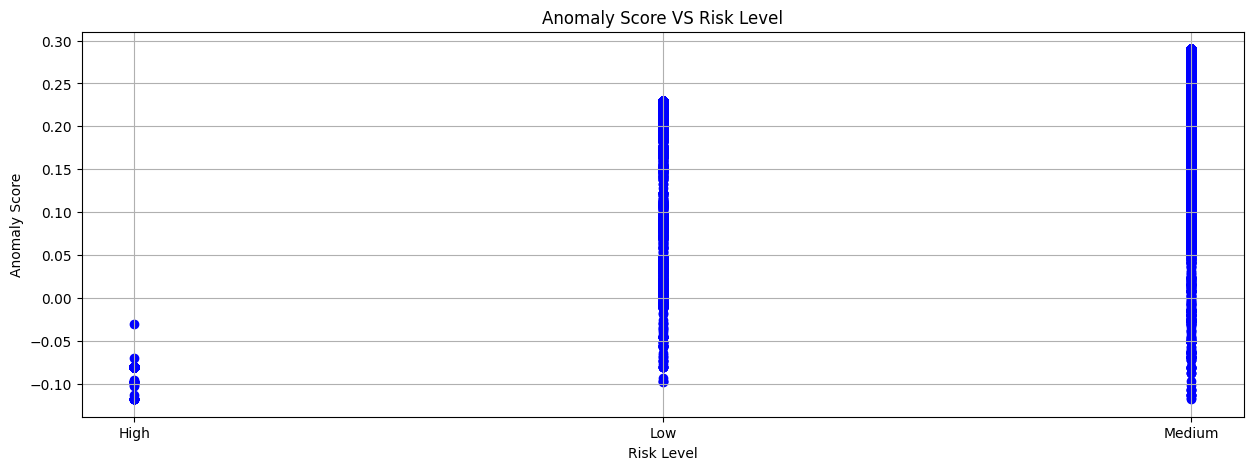

In [110]:
plt.figure(figsize = (15 , 5))
plt.scatter( new_df['Risk_Level'] , new_df['Anomaly_Score'] , c = 'b')
plt.title('Anomaly Score VS Risk Level')
plt.ylabel('Anomaly Score')
plt.xlabel('Risk Level' , )
plt.grid(True)
plt.show()

In [111]:
# Risk level grouping based on if it Is_Anomaly or not
new_df['Risk_Level'].groupby(new_df['Is_Anomaly?']).value_counts()

Is_Anomaly?  Risk_Level
0            Medium        22857
             Low            5050
1            High           1042
             Medium          169
             Low             113
Name: count, dtype: int64

In [112]:
# calculating mean and sorting them
new_df.groupby('Risk_Level')['Anomaly_Score'].mean().sort_values()

,Anomaly_Score
Risk_Level,
High,-0.080643
Low,0.161322
Medium,0.235403


# 🔴 Top 10 IP/User Classification

In [113]:
new_df[['TimeCreated' , 'Risk_Level' , 'Anomaly_Score' , 'Is_Anomaly?']].sort_values('Anomaly_Score').head(10)

,TimeCreated,Risk_Level,Anomaly_Score,Is_Anomaly?
20320,-0.283027,High,-0.118046,1
20298,-0.293259,High,-0.118046,1
20277,-0.297400,High,-0.118046,1
25262,-0.651127,High,-0.118046,1
25284,-0.644793,High,-0.118046,1
28748,-0.901318,Medium,-0.118046,1
31439,-0.884996,High,-0.118046,1
5731,2.042753,High,-0.118046,1
13931,-0.096175,High,-0.118046,1
13910,-0.100804,High,-0.118046,1


In [114]:
new_df['SubjectUserName'].value_counts().head(10)

,count
SubjectUserName,
4,28189
5,578
2,281
0,101
6,71
3,6
1,5


In [115]:
# Threat classification based on past analyses and bool features
def classify_threat(data):

    if data['ProcessFromDownloads'] == 1 or data['IsPayloadLikeName'] == 1 :
        return 'Malware / Suspicious Process Activity'

    if data['ElevationOccurred'] == 1 :
        return "Privilege Escalation"

    if data['IsCredentialRead'] == 1 :
        return 'Credential Access / Credential Theft'

    if data['SAMAccess'] == 1 :
        return 'Recon / Enumeration Activity'

    if data['IsLoginFail'] == 1 :
        return 'Unauthorized Access Attempt'

    return 'Normal Activity'

new_df['ThreatType'] = new_df.apply(classify_threat , axis = 1)

new_df[['EventID' , 'ThreatType']].head(20)

,EventID,ThreatType
0,17.122949,Normal Activity
1,4.768828,Privilege Escalation
2,4.768828,Privilege Escalation
3,4.768828,Privilege Escalation
4,4.785706,Normal Activity
5,5.278352,Normal Activity
6,4.784651,Normal Activity
7,4.768828,Privilege Escalation
8,5.513598,Credential Access / Credential Theft
9,5.513598,Credential Access / Credential Theft


In [116]:
new_df.loc[(new_df['Risk_Level'] == 'High') | (new_df['Is_Anomaly?'] == 1) , 'ThreatType'] = 'Suspicious Activity'
new_df

,TimeCreated,EventID,Channel,SourceName,SubjectUserName,ProcessName,NewProcessName,ParentProcessName,IpAddress,UserEventFrequency,...,IsLoginFail,IsLoginSuccess,PCA1,PCA2,Risk_Cluster,Risk_Level,Prediction,Anomaly_Score,Is_Anomaly?,ThreatType
0,2.030572,17.122949,0,2,5,18,14,9,6,-5.168684,...,0,0,15.617924,2.303227,1,High,-1,-0.079999,1,Suspicious Activity
1,2.025212,4.768828,3,1,0,1,14,9,6,-5.261298,...,0,0,7.096629,2.130548,1,High,-1,-0.079999,1,Suspicious Activity
2,2.025212,4.768828,3,1,0,1,14,9,6,-5.261298,...,0,0,7.038410,2.159473,1,High,-1,-0.079999,1,Suspicious Activity
3,2.025212,4.768828,3,1,0,13,14,9,6,-5.261298,...,0,0,7.038767,2.159296,1,High,-1,-0.079999,1,Suspicious Activity
4,2.025212,4.785706,3,1,0,3,14,9,6,-5.261298,...,0,0,7.007727,2.157908,1,High,-1,-0.079999,1,Suspicious Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31481,-0.892548,4.167526,1,0,5,18,14,9,6,-5.168684,...,0,0,6.536316,-0.760999,1,High,-1,-0.079999,1,Suspicious Activity
31482,-0.892548,4.167526,1,0,5,18,14,9,6,-5.168684,...,0,0,6.536308,-0.760995,1,High,-1,-0.079999,1,Suspicious Activity
31483,-0.892548,4.167526,1,0,5,18,14,9,6,-5.168684,...,0,0,6.536313,-0.760998,1,High,-1,-0.079999,1,Suspicious Activity
31484,-0.892548,4.167526,1,0,5,18,14,9,6,-5.168684,...,0,0,6.536313,-0.760998,1,High,-1,-0.079999,1,Suspicious Activity


In [117]:
new_df['ThreatType'].value_counts()

,count
ThreatType,
Normal Activity,27907
Suspicious Activity,1324


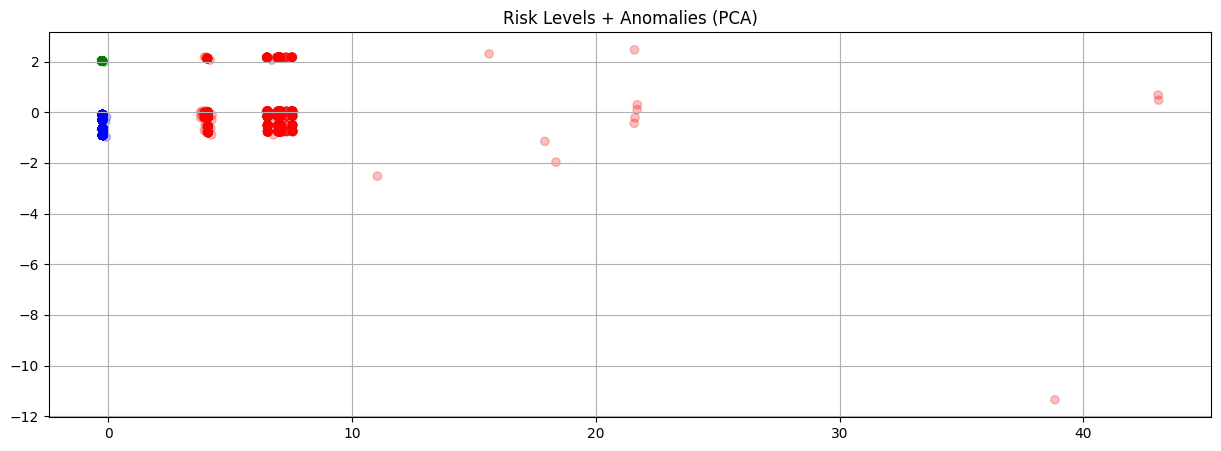

In [118]:
plt.figure(figsize = (15 , 5))
colors = new_df['Risk_Level'].map({'High' : 'red' , 'Medium' : 'blue' , 'Low' : 'green'})
plt.scatter(new_df['PCA1'] , new_df['PCA2'] , c = colors  , alpha = 0.25 )
plt.title('Risk Levels + Anomalies (PCA)')
plt.grid(True)
plt.show()

In [119]:
higher_10 = new_df[new_df['Risk_Level'] == 'High'].sort_values('Anomaly_Score').head(20)
higher_10.head(10)

,TimeCreated,EventID,Channel,SourceName,SubjectUserName,ProcessName,NewProcessName,ParentProcessName,IpAddress,UserEventFrequency,...,IsLoginFail,IsLoginSuccess,PCA1,PCA2,Risk_Cluster,Risk_Level,Prediction,Anomaly_Score,Is_Anomaly?,ThreatType
31439,-0.884996,0.683138,4,4,5,18,14,9,6,-5.168684,...,0,0,4.003812,-0.752449,1,High,-1,-0.118046,1,Suspicious Activity
31421,-0.893035,0.683138,4,4,5,18,14,9,6,-5.168684,...,0,0,3.935490,-0.726485,1,High,-1,-0.118046,1,Suspicious Activity
25284,-0.644793,0.683138,4,4,5,18,14,9,6,-5.168684,...,0,0,4.019630,-0.521848,1,High,-1,-0.118046,1,Suspicious Activity
25262,-0.651127,0.683138,4,4,5,18,14,9,6,-5.168684,...,0,0,3.969622,-0.503291,1,High,-1,-0.118046,1,Suspicious Activity
20298,-0.293259,0.683138,4,4,5,18,14,9,6,-5.168684,...,0,0,4.036260,-0.181127,1,High,-1,-0.118046,1,Suspicious Activity
20277,-0.297400,0.472155,4,4,5,18,14,9,6,-5.168684,...,0,0,3.845336,-0.166504,1,High,-1,-0.118046,1,Suspicious Activity
20320,-0.283027,0.683138,4,4,5,18,14,9,6,-5.168684,...,0,0,4.000097,-0.153002,1,High,-1,-0.118046,1,Suspicious Activity
13931,-0.096175,0.683138,4,4,5,18,14,9,6,-5.168684,...,0,0,4.028791,0.018237,1,High,-1,-0.118046,1,Suspicious Activity
5731,2.042753,0.683138,4,4,5,18,14,9,6,-5.168684,...,0,0,3.985625,2.163090,1,High,-1,-0.118046,1,Suspicious Activity
13953,-0.084725,0.683138,4,4,5,18,14,9,6,-5.168684,...,0,0,3.977061,0.055305,1,High,-1,-0.118046,1,Suspicious Activity


In [120]:
medium_10 = new_df[(new_df['Risk_Level'] == 'Medium') & (new_df['Is_Anomaly?'] == 1)].sort_values('Anomaly_Score').head(20)
medium_10.head(10)

,TimeCreated,EventID,Channel,SourceName,SubjectUserName,ProcessName,NewProcessName,ParentProcessName,IpAddress,UserEventFrequency,...,IsLoginFail,IsLoginSuccess,PCA1,PCA2,Risk_Cluster,Risk_Level,Prediction,Anomaly_Score,Is_Anomaly?,ThreatType
28748,-0.901318,-0.133367,2,3,4,17,13,8,5,0.192257,...,0,0,-0.227485,-0.899569,0,Medium,-1,-0.118046,1,Suspicious Activity
29137,-0.900100,-0.133367,2,3,4,17,13,8,5,0.192257,...,0,0,-0.225550,-0.899321,0,Medium,-1,-0.116967,1,Suspicious Activity
19541,-0.291797,-0.148136,2,3,4,17,13,8,5,0.192257,...,0,0,-0.248733,-0.289242,0,Medium,-1,-0.113204,1,Suspicious Activity
30271,-0.895715,-0.148136,2,3,4,17,13,8,5,0.192257,...,0,0,-0.243280,-0.891487,0,Medium,-1,-0.113204,1,Suspicious Activity
23810,-0.655756,-0.133367,2,3,4,17,13,8,5,0.192257,...,0,0,-0.227424,-0.655819,0,Medium,-1,-0.112668,1,Suspicious Activity
12355,-0.098611,-0.135477,2,3,4,17,13,8,5,0.192257,...,0,0,-0.238154,-0.098147,0,Medium,-1,-0.112668,1,Suspicious Activity
25472,-0.906434,-0.133367,2,3,4,17,13,8,5,0.192257,...,0,0,-0.224302,-0.906229,0,Medium,-1,-0.112668,1,Suspicious Activity
24162,-0.653807,-0.150246,2,3,4,17,13,8,5,0.192257,...,0,0,-0.247990,-0.649756,0,Medium,-1,-0.106794,1,Suspicious Activity
29888,-0.897908,-0.135477,2,3,4,17,13,8,5,0.192257,...,0,0,-0.223912,-0.898720,0,Medium,-1,-0.106794,1,Suspicious Activity
30635,-0.894497,-0.150246,2,3,4,17,13,8,5,0.192257,...,0,0,-0.245705,-0.889835,0,Medium,-1,-0.106794,1,Suspicious Activity


In [121]:
low_rare = new_df[(new_df['Risk_Level'] == 'Low') & (new_df['Is_Anomaly?'] == 1)].sort_values('Anomaly_Score').head(20)
low_rare.head(10)

,TimeCreated,EventID,Channel,SourceName,SubjectUserName,ProcessName,NewProcessName,ParentProcessName,IpAddress,UserEventFrequency,...,IsLoginFail,IsLoginSuccess,PCA1,PCA2,Risk_Cluster,Risk_Level,Prediction,Anomaly_Score,Is_Anomaly?,ThreatType
4509,2.032277,-0.133367,2,3,4,17,13,8,5,0.192257,...,0,0,-0.251814,2.024827,2,Low,-1,-0.098282,1,Suspicious Activity
4122,2.030815,-0.133367,2,3,4,17,13,8,5,0.192257,...,0,0,-0.249920,2.022435,2,Low,-1,-0.097058,1,Suspicious Activity
3727,2.030085,-0.133367,2,3,4,17,13,8,5,0.192257,...,0,0,-0.249594,2.021547,2,Low,-1,-0.096533,1,Suspicious Activity
4126,2.031059,-0.135477,2,3,4,17,13,8,5,0.192257,...,0,0,-0.251028,2.022466,2,Low,-1,-0.093389,1,Suspicious Activity
1021,2.026187,-0.133367,2,3,4,17,13,8,5,0.192257,...,0,0,-0.248150,2.016960,2,Low,-1,-0.079999,1,Suspicious Activity
1719,2.026918,-0.133367,2,3,4,17,13,8,5,0.192257,...,0,0,-0.248112,2.017666,2,Low,-1,-0.079999,1,Suspicious Activity
1989,2.027405,-0.133367,2,3,4,17,13,8,5,0.192257,...,0,0,-0.248114,2.018151,2,Low,-1,-0.079999,1,Suspicious Activity
4511,2.032277,-0.133367,2,3,4,17,13,8,5,0.192257,...,0,0,-0.248270,2.023066,2,Low,-1,-0.079999,1,Suspicious Activity
2644,2.028379,-0.133367,2,3,4,17,13,8,5,0.192257,...,0,0,-0.248136,2.019130,2,Low,-1,-0.079999,1,Suspicious Activity
2870,2.028379,-0.133367,2,3,4,17,13,8,5,0.192257,...,0,0,-0.248165,2.019144,2,Low,-1,-0.079999,1,Suspicious Activity


# 🔴 Graph Network Analysis

✅ creating a graph where nodes are IPs and edges represent events using networkx library

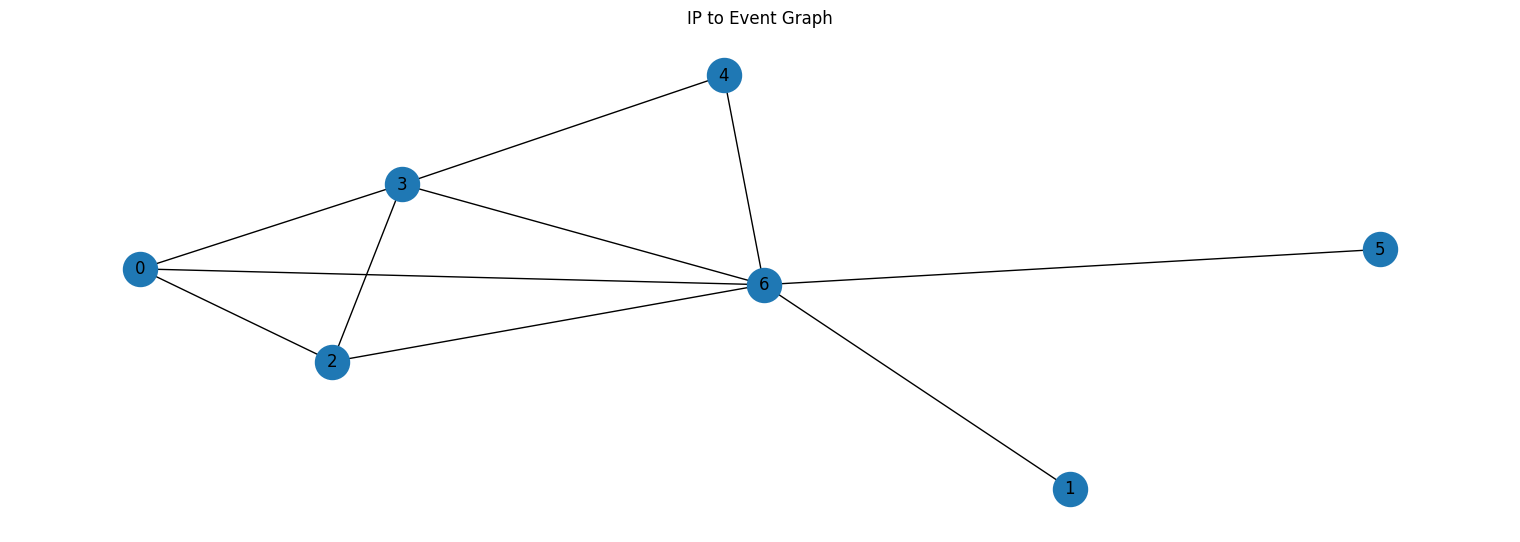

In [122]:
import networkx as nx

new_df_graph = new_df[['IpAddress']]

G = nx.Graph()
previous_ip = None

for ip in new_df_graph['IpAddress'] :
  if previous_ip is not None and ip != previous_ip :
    G.add_edge(previous_ip, ip)
  previous_ip = ip

plt.figure(figsize = (15 , 5))
nx.draw( G , with_labels = True , node_size = 600)
plt.title('IP to Event Graph')
plt.show()


✅	Computing degree centrality to identify key nodes

In [123]:
degree_centrality = nx.degree_centrality(G)
centrality_new_df = pd.DataFrame.from_dict(degree_centrality , orient = 'index' , columns = ['DegreeCentrality'])
centrality_new_df = centrality_new_df.sort_values('DegreeCentrality' , ascending = False )
print(f'Top 10 Most Central IPs :\n{centrality_new_df.head(10)}')

Top 10 Most Central IPs :
   DegreeCentrality
6          1.000000
3          0.666667
2          0.500000
0          0.500000
4          0.333333
1          0.166667
5          0.166667


✅ Here we created the same paragraph but added weight to the edges

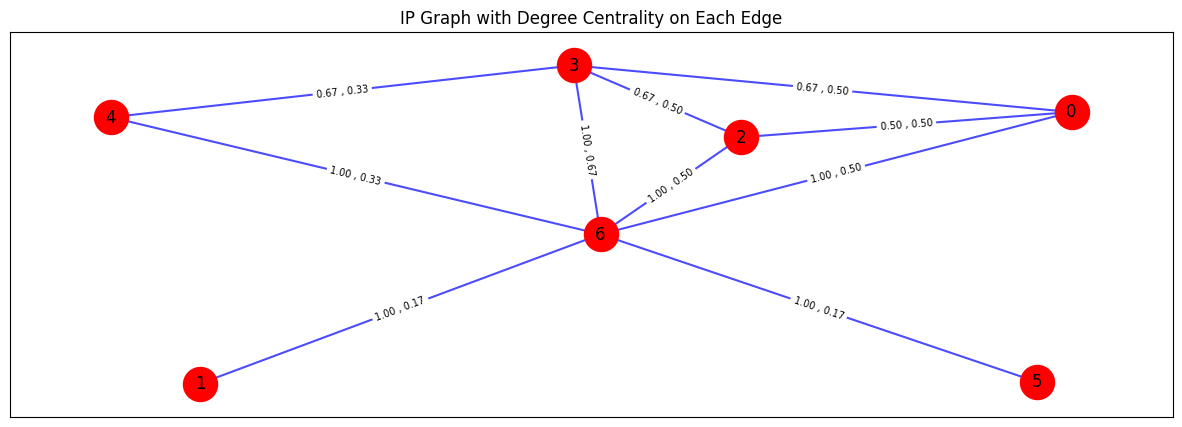

In [124]:
edge_labels = {}
for u , v in G.edges() :
  edge_labels[(u, v)] = f'{degree_centrality[u]:.2f} , {degree_centrality[v]:.2f}'


plt.figure(figsize = (15 , 5))

pos = nx.spring_layout(G , k = 0.3 , iterations = 30)
nx.draw_networkx_nodes(G , pos , node_size = 600 , node_color = 'red' )

nx.draw_networkx_edges(G , pos,width = 1.5 , edge_color = 'blue' , alpha = 0.7)
nx.draw_networkx_labels(G, pos)

nx.draw_networkx_edge_labels(G , pos ,edge_labels = edge_labels , font_size = 7 , label_pos = 0.5)

plt.title('IP Graph with Degree Centrality on Each Edge')
plt.show()

# 🔴 Real-Time Bot Implementation

✅ here I save all trained security models and preprocessing components into a single file for later reuse in real-time detection.

In [125]:
import joblib

artifacts = {
    'most_imp_features' : most_imp_features , 'risk_map' : risk_map , 'scaler' : scaler ,
    'pca_iso' : pca , 'iso' : iso , 'kmeans' : kmeans}

joblib.dump(artifacts , 'security_artifacts.joblib')
print('Saved : security_artifacts.joblib')


Saved : security_artifacts.joblib


✅ The bot continuously analyzes incoming log events in real time and detects suspicious behavior using clustering and anomaly detection models.

In [126]:
import time
import json
import os
import csv
from collections import defaultdict
from watchdog.observers import Observer
from watchdog.events import FileSystemEventHandler

LOG_FILE = '/content/alerts.log'
ARTIFACTS_PATH = './security_artifacts.joblib'

art = joblib.load(ARTIFACTS_PATH)
most_imp_features = art['most_imp_features']
risk_map = art['risk_map']
scaler = art['scaler']
pca = art['pca_iso']
iso = art['iso']
kmeans = art['kmeans']

user_event_counter = defaultdict(int)

def parse_log_line(line: str):
  data = json.loads(line.strip())
  return pd.DataFrame([data])


def analyze_event(df_raw):

    try:
        user = (
            df_raw.get('TargetUserName', ['UNKNOWN'])[0]
            if 'TargetUserName' in df_raw.columns
            else 'UNKNOWN'
            )

        user_event_counter[user] += 1

        for col in most_imp_features:
            if col not in df_raw.columns:
                df_raw[col] = 0

        df_raw['UserEventCount'] = user_event_counter[user]

        if 'TimeCreated' in df_raw.columns:
            df_raw['TimeCreated'] = pd.to_datetime(df_raw['TimeCreated'] , errors = 'coerce').astype('int64') // 10**9

        X = df_raw[most_imp_features]

        X = X + np.random.normal(0 , 0.01 , X.shape)

        X_std = scaler.transform(X)

        X_pca = pca.transform(X_std)
        X_for_kmeans = X_pca[: , : kmeans.n_features_in_]

        risk_cluster = int(kmeans.predict(X_for_kmeans)[0])
        risk_level = risk_map.get(risk_cluster , 'Unknown')

        X_for_iso = X_pca[: , : iso.n_features_in_]

        iso_pred = int(iso.predict(X_for_iso)[0])
        iso_score = float(iso.decision_function(X_for_iso)[0])

        return {'risk_cluster': risk_cluster , 'risk_level': risk_level , 'iso_pred': iso_pred ,
                'iso_score' : iso_score , 'user': user , 'count' : user_event_counter[user]}

    except Exception as e:
        print('ERROR in analyze_event :' , e)
        return None

def log_for_dashboard(result):
    with open('dashboard_data.csv' , 'a' , newline = '') as f:
        writer = csv.writer(f)
        writer.writerow([ time.time() , result['user'] , result['risk_level'] , result['risk_cluster'] , result['iso_score']])


def alert_if_suspicious(result, raw_line):

    if result is None :
        return

    log_for_dashboard(result)

    if result['risk_level'] == 'High' or result['iso_pred'] == -1 :
        print('\n ALERT : Suspicious Event')
        print('User : ' , result['user'])
        print('Event Count : ' , result['count'])
        print('Risk Level : ' , result['risk_level'])
        print('Cluster : ' , result['risk_cluster'])
        print('ISO Result : ' , 'Anomaly' if result['iso_pred'] == -1 else 'Normal')
        print('ISO Score : ' , result['iso_score'])
        print('Raw Log :' , raw_line.strip())
        print('-' * 60)

class LogFileHandler(FileSystemEventHandler):

    def __init__(self):
        self.last_line = None

    def on_modified(self , event) :

        if event.src_path != os.path.abspath(LOG_FILE):
            return

        with open(LOG_FILE, 'r', encoding = 'utf-8') as f :
            lines = f.readlines()

        if not lines:
            return

        last_line = lines[-1]

        if last_line == self.last_line :
            return

        self.last_line = last_line

        df_raw = parse_log_line(last_line)
        if df_raw is not None :
            result = analyze_event(df_raw)
            alert_if_suspicious(result, last_line)


if __name__ == '__main__' :

    print('Real-Time Security Bot Running ')
    print('Watching file : ' , LOG_FILE)

    observer = Observer()
    observer.schedule(LogFileHandler() , path = os.path.dirname(LOG_FILE) or '.' , recursive=False )
    observer.start()

    try:
        while True :
            time.sleep(1)
    except KeyboardInterrupt :
        observer.stop()

    observer.join()


Real-Time Security Bot Running 
Watching file :  /content/alerts.log


# 🔴 Dashboard and Visualization

✅ The streamlit creates a real-time dashboard that visualizes security risk levels and anomaly scores from detected events.

In [127]:
import streamlit as st
import os
import time

st.set_page_config(page_title = 'Security Dashboard' , layout = 'wide')

DATA_FILE = 'dashboard_data.csv'

st.title('Real-Time Security Monitoring Dashboard')

@st.cache_data(ttl=2)
@st.cache_data(ttl=2)

def load_data():
    if not os.path.exists(DATA_FILE) :
        df = pd.DataFrame(columns = [ 'timestamp' , 'user' , 'risk_level' , 'cluster' , 'iso_score' ])
    else :
        df = pd.read_csv(DATA_FILE , names = ['timestamp' , 'user' , 'risk_level' , 'cluster' , 'iso_score'])

    if not df.empty :
        df['time'] = pd.to_datetime(df['timestamp'] , unit = 's')
    else :
        df['time'] = pd.NaT

    return df

df = load_data()

col1, col2, col3, col4 = st.columns(4)

col1.metric('Total Events' , len(df))
col2.metric('High Risk Alerts' , len(df[df['risk_level'] == 'High']))
col3.metric('Unique Users' , df['user'].nunique())
col4.metric('Avg ISO Score' , round(df['iso_score'].mean() , 4) if len(df) else 0)
st.divider()

st.subheader('Recent Alerts')
st.dataframe(df.sort_values('time' , ascending = False).head(10) , use_container_width = True)

st.subheader('Top Users by Activity')
top_users = df['user'].value_counts().head(5)
st.bar_chart(top_users)

st.subheader('Anomaly Score Distribution')

fig, ax = plt.subplots()
ax.scatter(df['cluster'] , df['iso_score'] , c = df['iso_score'] , cmap = 'coolwarm' , alpha = 0.7)
ax.set_xlabel('Risk Cluster')
ax.set_ylabel('Isolation Forest Score')
ax.set_title('Cluster vs Anomaly Score')
st.pyplot(fig)
st.caption('Dashboard auto-refreshes every 2 seconds')

2025-12-20 19:10:47.620 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-20 19:10:47.622 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-20 19:10:47.624 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-20 19:10:47.625 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-20 19:10:47.627 No runtime found, using MemoryCacheStorageManager
2025-12-20 19:10:47.630 No runtime found, using MemoryCacheStorageManager
2025-12-20 19:10:47.631 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-20 19:10:47.631 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-20 19:10:47.632 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor

DeltaGenerator()



---



---



---



---



---



#   **This is my work, I hope you liked it.**



---



---



---



---



---

